In [231]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [232]:
#input : study hours
x = np.array([1,2,3,4,5]).reshape(-1,1)
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [233]:
# x.reshape(1,-1)

y = np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [234]:
#create and train the model

model = LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [235]:
#display regression paremeter

print("Intercept: ", model.intercept_)
print("SLope: ", model.coef_[0])


Intercept:  33.0
SLope:  7.0


In [236]:
#Predict marks for six study hours

new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

print("Predicted mark: ", predicted_mark[0])

Predicted mark:  75.0


In [237]:
#predict for the original oberservation

y_pred = model.predict(x)
y_pred 

array([40., 47., 54., 61., 68.])

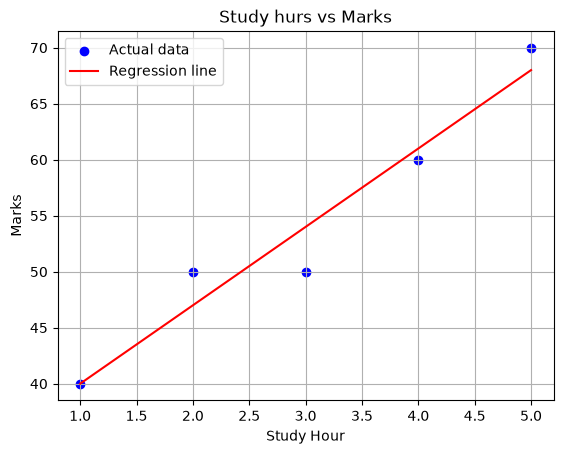

In [238]:
#plot the data and regression line
import matplotlib.pyplot as plt
plt.scatter(x,y, color = "blue", label="Actual data")
plt.plot(x,y_pred, color="Red", label= "Regression line")

plt.xlabel("Study Hour")
plt.ylabel("Marks")
plt.title("Study hurs vs Marks")
plt.legend()
plt.grid(True)
plt.show()

Evalution the python model

--- for linear regression, to measure how our model is accurate we use some measure those are : performance metrics like: MSE, MAE,RMASE, R-squared

In [239]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [240]:
mae = mean_absolute_error(y,y_pred)
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score: ", r2)

MAE: 2.0
MSE: 6.0
RMSE: 2.449489742783178
R2 Score:  0.9423076923076923


Train - Test split example

In [241]:
from sklearn.model_selection import train_test_split

data = {
    "Study_hour": [1,2,3,4,5,6,7,8,9,10],
    "Marks" : [32,38,43,50,54,61,68,73,81,88]
}


Wehn we use array we have to make it 2D but when we use Dataframe then we have no need to convert it in 2D

In [242]:
df = pd.DataFrame(data)

df

,Study_hour,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [243]:
x = df[["Study_hour"]]
y = df[["Marks"]]

x

,Study_hour
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [244]:
y

,Marks
0,32
1,38
2,43
3,50
4,54
5,61
6,68
7,73
8,81
9,88


In [245]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [246]:
print("Interception: ", model.intercept_)
print("Slope: ", model.coef_[0])

print("Actual values: \n", y_test.values)
print("\nPredicted values: \n", y_pred)

Interception:  [24.72413793]
Slope:  [6.1637931]
Actual values: 
 [[81]
 [38]]

Predicted values: 
 [[80.19827586]
 [37.05172414]]


In [247]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score: ", r2)

MAE: 0.875
MSE: 0.7709943519619504
RMSE: 0.8780628405541089
R2 Score:  0.9983320836085193


Multiple Linear Regression in python

In [248]:
data = {
    "Study_hour": [2,3,4,5,6,7,8,9],
    "aten" : [60,65,70,75,80,85,90,95],
    "ass_sc" : [50,55,58,65,70,74,80,88],
    "final_mark" : [42,48,54,61,67,73,81,89]

}

df = pd.DataFrame(data)

df


,Study_hour,aten,ass_sc,final_mark
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


In [249]:
x = df.iloc[:,0:3]
y = df["final_mark"]

x

,Study_hour,aten,ass_sc
0,2,60,50
1,3,65,55
2,4,70,58
3,5,75,65
4,6,80,70
5,7,85,74
6,8,90,80
7,9,95,88


In [250]:
y

0    42
1    48
2    54
3    61
4    67
5    73
6    81
7    89
Name: final_mark, dtype: int64

In [251]:
model = LinearRegression()
model.fit(x, y)
print("Intercept: ", model.intercept_)

Intercept:  -28.31652806652808


In [255]:
coefficient_table = pd.DataFrame({
    "Feature" : x.columns,
    "Coefficient" : model.coef_
})

print(coefficient_table)

      Feature  Coefficient
0  Study_hour     0.131410
1        aten     0.657051
2      ass_sc     0.608108


In [257]:
new_stu = pd.DataFrame({
    "Study_hour" : [6],
    "aten" : [82],
    "ass_sc" : [72]
})

prediction = model.predict(new_stu)

print("Predicted Final Mark: ", prediction[0])

Predicted Final Mark:  70.13392238392238


Using Dataset

work - for multiple data, 
        make csv,
        go thorugh everything again,


from 2 dataset: do same thing. and analysis with graph